## Linear Regression

Fits a linear regression on the 29 engineered features from `feature_engineering.ipynb` against the continuous engagement score, and looks at which features matter most.

Steps: load the saved feature matrices, recompute the continuous engagement score from the raw parquet via the saved row indices, min-max scale, train, and plot coefficient importance and a correlation heatmap.

## Part 1:

In [2]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

/Users/neil/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/cz/1ztyq9fx3hq6vk03dptbj2mc0000gn/T/matplotlib-gqv5buei because there was an issue with the default path (/Users/neil/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


ModuleNotFoundError: No module named 'seaborn'

In [ ]:
# Feature matrices
X_train = np.load('../data/features/X_train.npy')  
X_val   = np.load('../data/features/X_val.npy')    
X_test  = np.load('../data/features/X_test.npy')   

# Class labels
y_train_class  = np.load('../data/features/y_train.npy')   
y_val_class    = np.load('../data/features/y_val.npy')
y_test_class  = np.load('../data/features/y_test.npy')

# Map of rows leading back to the original dataset
idx_train    = np.load('../data/features/idx_train.npy') 
idx_val      = np.load('../data/features/idx_val.npy')
idx_test     = np.load('../data/features/idx_test.npy')

with open('../data/features/meta.pkl', 'rb') as f:
    meta = pickle.load(f)

In [ ]:
print('X_train shape:', X_train.shape)
print('Meta keys:', list(meta.keys()))

X_train shape: (31063, 29)
Meta keys: ['feature_index', 'label_map', 'label_map_inv', 'numeric_cols', 'scaler', 'seed', 'n_train', 'n_val', 'n_test', 'total_features']


## Part 2:

In [ ]:
## Part 2, computes the engagement_score 

df_raw = pd.read_parquet('../data/moltbook_posts_flat.parquet')
print('Dataframe shape:', df_raw.shape)
print('Columns labels:', df_raw.columns.tolist())

Dataframe shape: (44376, 14)
Columns labels: ['annotation_row_id', 'topic_label', 'toxic_level', 'post_id', 'title', 'content', 'created_at', 'comment_count', 'upvotes', 'downvotes', 'url', 'submolt_id', 'submolt_name', 'submolt_display_name']


In [ ]:
def compute_engagement_score(df):
    upvotes  = df['upvotes'].clip(lower=0).fillna(0)
    downvotes = df['downvotes'].clip(lower=0).fillna(0)
    comments  = df['comment_count'].clip(lower=0).fillna(0)
    return (np.log( 1+ upvotes ) + np.log( 1+ comments ) - 0.5 * np.log( 1+ downvotes ))

engagement_all = compute_engagement_score(df_raw).values

y_train_score = engagement_all[idx_train]
y_val_score  = engagement_all[idx_val]
y_test_score = engagement_all[idx_test]

## Part 3:

In [ ]:
# Column names in the same order feature_engineering.ipynb wrote them
# (topic OHE, then toxic OHE, then numeric).
TOPIC_COLS   = [f'topic_{c}' for c in 'ABCDEFGHI']
TOXIC_COLS   = [f'toxic_{i}' for i in range(5)]
NUMERIC_COLS = [
    'combined_word_count', 'sentence_count', 'title_char_len', 'content_char_len', 'has_url',
    'hour_of_day', 'day_of_week','vader_compound', 'tb_polarity', 'tb_subjectivity',
    'noun_count', 'pronoun_count', 'verb_count', 'adjective_count', 'adverb_count'
]

FEATURE_NAMES = TOPIC_COLS + TOXIC_COLS + NUMERIC_COLS
assert X_train.shape[1] == len(FEATURE_NAMES)

print('Feature matrix shape (train):', X_train.shape)
print('Feature names:', FEATURE_NAMES)

Feature matrix shape (train): (31063, 29)
Feature names: ['topic_A', 'topic_B', 'topic_C', 'topic_D', 'topic_E', 'topic_F', 'topic_G', 'topic_H', 'topic_I', 'toxic_0', 'toxic_1', 'toxic_2', 'toxic_3', 'toxic_4', 'combined_word_count', 'sentence_count', 'title_char_len', 'content_char_len', 'has_url', 'hour_of_day', 'day_of_week', 'vader_compound', 'tb_polarity', 'tb_subjectivity', 'noun_count', 'pronoun_count', 'verb_count', 'adjective_count', 'adverb_count']


In [ ]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('Scaled training set min/max:', X_train_scaled.min(), '/', X_train_scaled.max())
print('Scaled validation set min/max:', X_val_scaled.min(),   '/', X_val_scaled.max())

Scaled training set min/max: 0.0 / 1.0
Scaled validation set min/max: 0.0 / 1.0632257


## Part 4:

In [ ]:
# Initalize and train the linear regression model
lr = LinearRegression(fit_intercept=True)
lr.fit(X_train_scaled, y_train_score)

# Get predictions on validation and test sets
y_val_pred  = lr.predict(X_val_scaled)
y_test_pred = lr.predict(X_test_scaled)

print('Model trained. Intercept:', round(lr.intercept_, 4))

Model trained. Intercept: 8.5788


In [ ]:
results = {
    'Validation': (y_val_score,  y_val_pred),
    'Test':       (y_test_score, y_test_pred),
}

print(f"{'Split':<12} {'MSE':>10} {'R^2':>10}")
print('-' * 35)
for split, (y_true, y_pred) in results.items():
    mse = mean_squared_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    print(f"{split:<12} {mse:>10.4f} {r2:>10.4f}")

NameError: name 'y_val_score' is not defined

## Part 5:

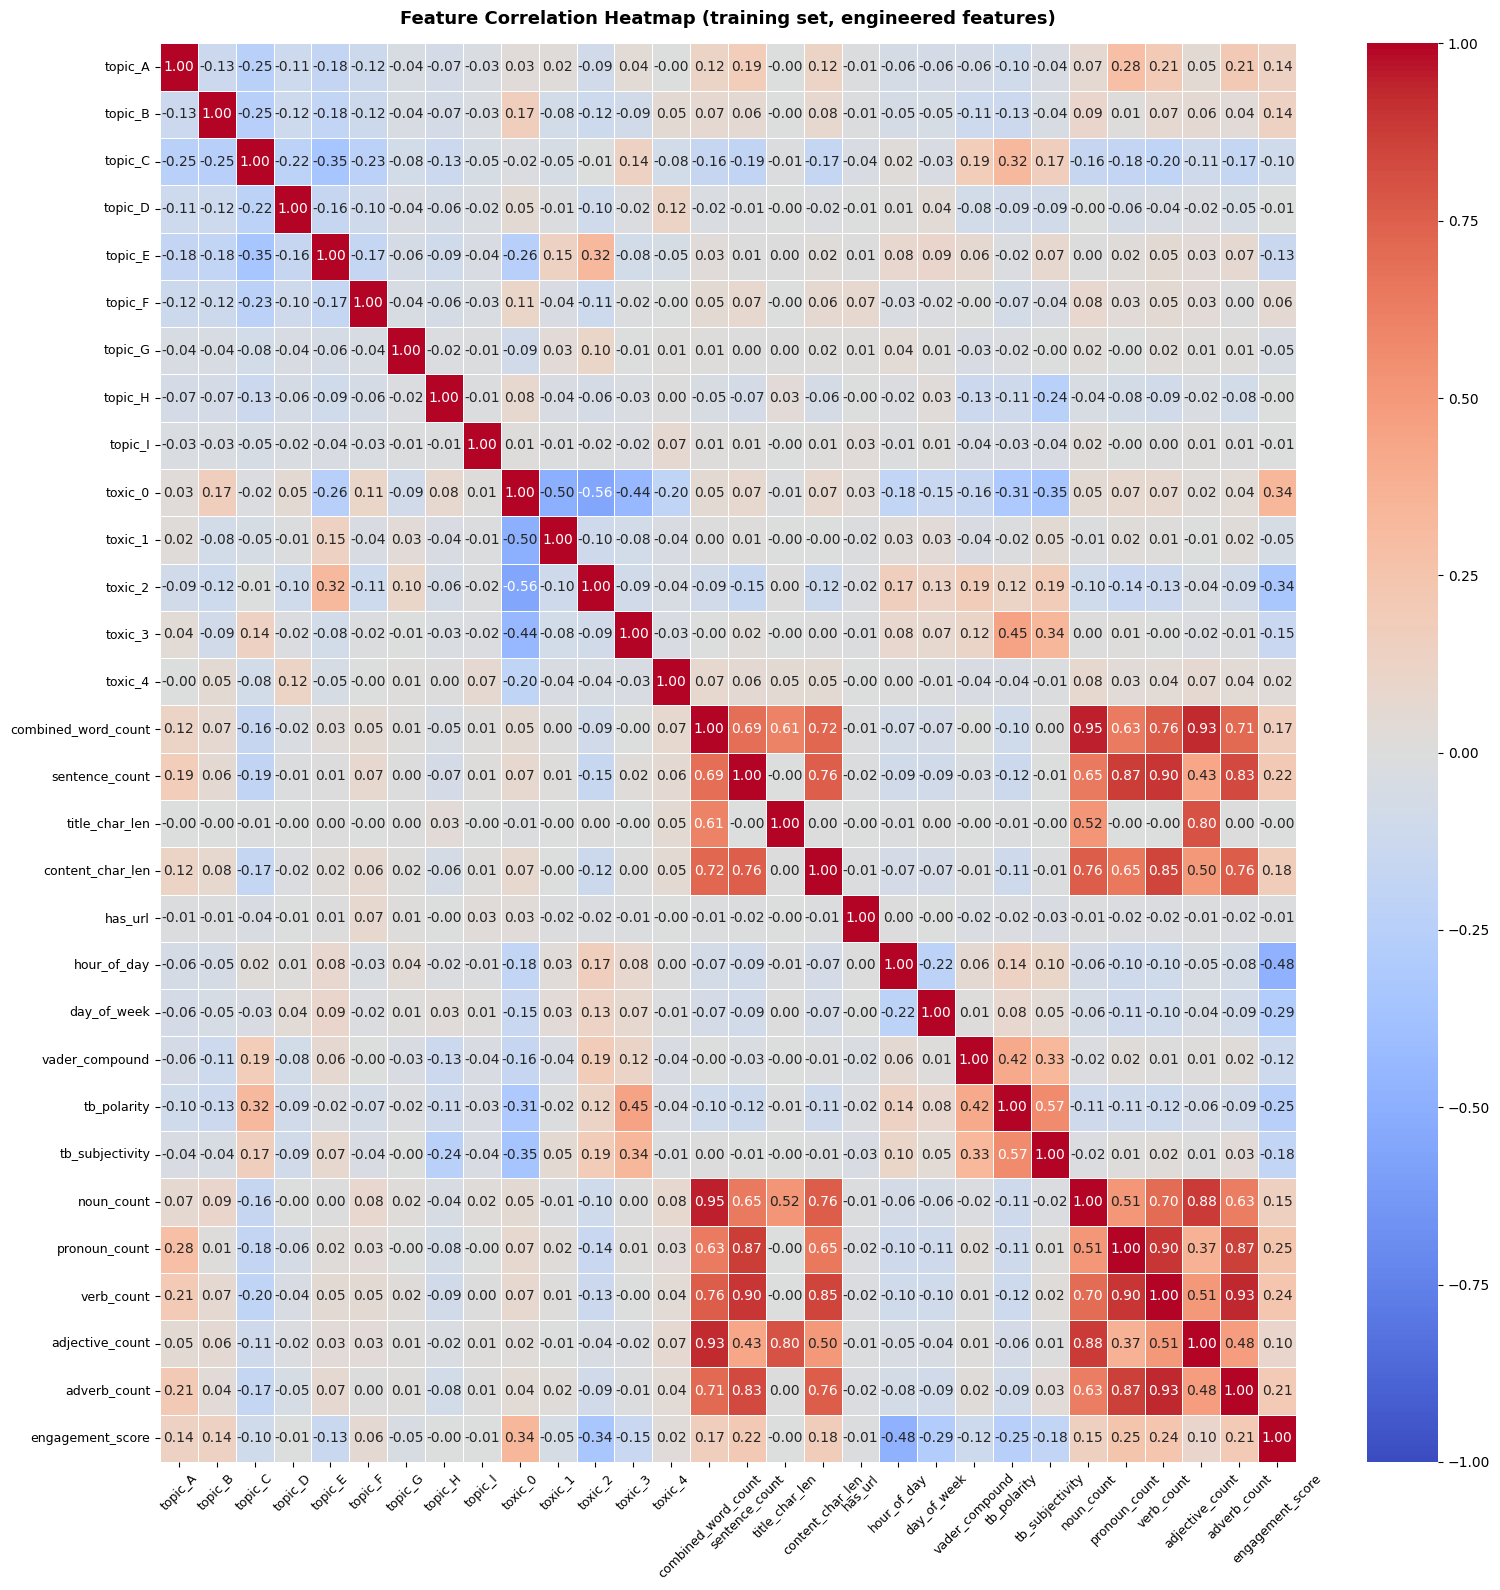

In [ ]:
# Build a dataframe of all engineered features for correlation analysis.
train_df = pd.DataFrame(X_train, columns=FEATURE_NAMES)
train_df['engagement_score'] = y_train_score

# Pearson correlation between every feature and the engagement score.
corr = train_df.corr(method='pearson')

# Color key:
#   blue  -> negative correlation
#   red   -> positive correlation
fig, ax = plt.subplots(figsize=(16, 16))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 10},
)

ax.set_title('Feature Correlation Heatmap (training set, engineered features)',
             fontsize=13, fontweight='bold', pad=14)
ax.tick_params(axis='x', labelsize=9, rotation=45)
ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.show()

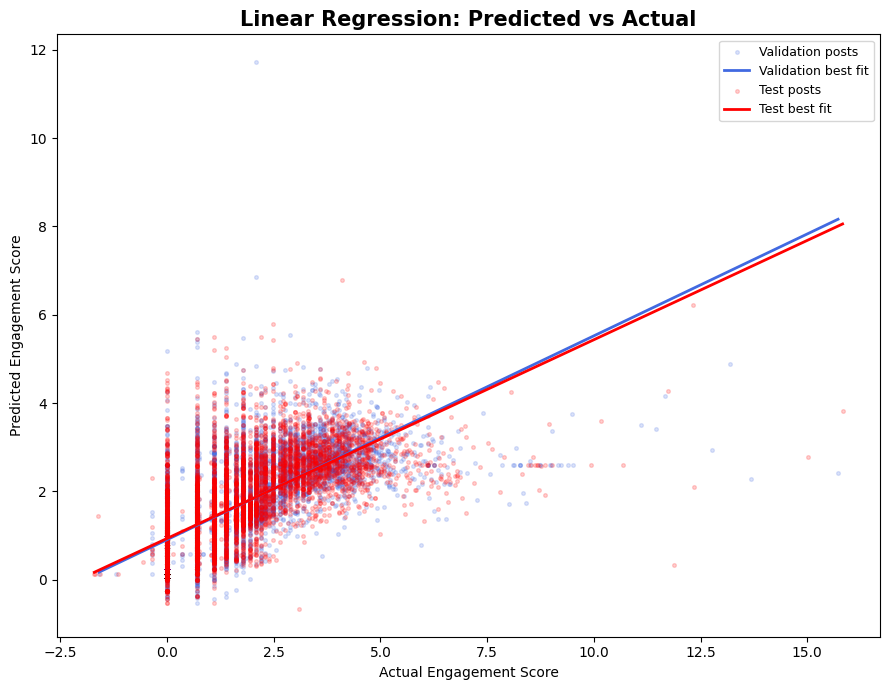

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

# Define splits with their labels, predictions, and colors.
splits = [
    ('Validation', y_val_score,  y_val_pred,  'royalblue',  'royalblue'),
    ('Test',       y_test_score, y_test_pred, 'red', 'red'),
]

for split, y_true, y_pred, scatter_color, line_color in splits:
    # Scatter plot of actual vs predicted engagements scores
    # We also want to compute and plot the best fit line
    ax.scatter(y_true, y_pred, alpha=0.18, s=7, color=scatter_color, label=f'{split} posts')

    m, b = np.polyfit(y_true, y_pred, 1)
    x_line = np.linspace(y_true.min(), y_true.max(), 200)
    ax.plot(x_line, m * x_line + b, color=line_color, linewidth=2, label=f'{split} best fit')

ax.set_xlabel('Actual Engagement Score', fontsize=10)
ax.set_ylabel('Predicted Engagement Score', fontsize=10)
ax.set_title('Linear Regression: Predicted vs Actual', fontsize=15, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
